# Cholesky, log-det, trace — the structured primitives tour

Every Gaussian computation in this curriculum eventually bottoms out into one of four scalar/array reductions of a covariance / precision operator $A$:

| Primitive | What it returns | Where it shows up |
|-----------|-----------------|-------------------|
| `cholesky(A)` | factor $L$ s.t. $A = L L^\top$ | sampling, log-density, conditioning |
| `logdet(A)` | $\log\lvert A\rvert$ | log-density, marginal likelihood, KL, entropy |
| `trace(A)` | $\sum_i A_{ii}$ | KL, ELBO, expected log-likelihood, score test |
| `diag(A)` | $(A_{11},\dots,A_{nn})$ | predictive marginal variance, calibration |

In gaussx these are **structurally dispatched**: hand them a `DiagonalLinearOperator` and you get an $\mathcal{O}(n)$ closed-form; hand them a `Kronecker(A,B)` and they exploit $\det(A\otimes B) = \det(A)^{n_B}\det(B)^{n_A}$; everything else falls back to dense Cholesky-via-LAPACK. The dispatch is invisible to the caller — this notebook makes it visible.

This is **not a list of identities** — those live in [0.3 — quadratic forms, entropy, KL](gaussian_quantities.ipynb). It's the *operational layer* underneath: which structures get cheap special-cases, what the cost is, and how the dispatch composes with the operator zoo from [0.8 — structured sampling](structured_sampling.ipynb).

Prerequisites: [0.1 — multivariate Gaussian](multivariate_gaussian.ipynb), [0.3 — Gaussian quantities](gaussian_quantities.ipynb), [0.8 — structured sampling](structured_sampling.ipynb).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import time
import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    BlockDiag, BlockTriDiag, Kronecker,
    cholesky, diag as gx_diag, logdet, trace as gx_trace,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

def random_psd(key, n, jitter=1e-3):
    A = jax.random.normal(key, (n, n))
    return A @ A.T + jitter * jnp.eye(n)

## The four primitives — what they compute

For a symmetric positive-definite (SPD) matrix $A \in \mathbb{R}^{n \times n}$, the **Cholesky factorisation** is the unique lower-triangular matrix $L$ with positive diagonal such that

```{math}
:label: eq:chol-defn
A \;=\; L L^\top.
```

Every other primitive in this section can be derived from $L$:

```{math}
:label: eq:logdet-from-chol
\log\lvert A \rvert \;=\; \log\bigl\lvert L L^\top \bigr\rvert \;=\; 2\sum_{i=1}^{n} \log L_{ii}.
```

```{math}
:label: eq:diag-from-chol
A_{ii} \;=\; \sum_{k=1}^{i} L_{ik}^{2}, \qquad \mathrm{tr}(A) \;=\; \sum_{i,k} L_{ik}^{2} \;=\; \lVert L \rVert_F^2.
```

[](#eq:logdet-from-chol) is the workhorse: $\log\lvert A\rvert$ never needs to materialise the full determinant — overflow / underflow is impossible because we sum logs of $n$ positive scalars. [](#eq:diag-from-chol) shows that the diagonal of $A$ and its trace are both quadratic forms in the rows of $L$.

:::{tip} ELI5
Cholesky is the *square root* of a covariance matrix — once you have $L$, you can sample from $\mathcal{N}(0,A)$ by $L\varepsilon$, you can log-determine by summing logs of the diagonal, and you can trace / diag by squaring rows. In gaussx, all four primitives wire through this single object — but they're **lazy** about computing it for structured operators that have closed-form shortcuts.
:::

## Dispatch — closed-form identities, compute, storage

The four primitives dispatch on operator type. To keep the picture honest we separate three orthogonal questions:

1. **Which closed-form identity is used?** (the math)
2. **What does it cost to compute?** (FLOPs / time)
3. **What does the operator and its factor occupy in memory?** (storage)

All three matter — a structure can have a cheap closed-form but bad storage (densified factor), or vice versa. The tables below cover the four operator types with full primitive coverage in gaussx today: `Diagonal`, `Kronecker`, `BlockDiag`, `BlockTriDiag`. (`LowRankUpdate` has dispatched `logdet` via the determinant lemma but no closed-form `cholesky` — it appears in [0.8 — structured sampling](structured_sampling.ipynb).)

### 1. Closed-form identities

| Operator | `cholesky(A)` | `logdet(A)` | `trace(A)` | `diag(A)` |
|---|---|---|---|---|
| `Diagonal(d)` | $\mathrm{diag}(\sqrt{d})$ | $\sum_i \log d_i$ | $\sum_i d_i$ | $d$ |
| `Kronecker(A,B)` | $L_A \otimes L_B$ | $n_B\log\lvert A\rvert + n_A\log\lvert B\rvert$ | $\mathrm{tr}(A)\,\mathrm{tr}(B)$ | $\mathrm{diag}(A)\otimes\mathrm{diag}(B)$ |
| `BlockDiag([A_k])` | $\mathrm{BlockDiag}(L_{A_k})$ | $\sum_k \log\lvert A_k\rvert$ | $\sum_k \mathrm{tr}(A_k)$ | $\mathrm{concat}(\mathrm{diag}(A_k))$ |
| `BlockTriDiag` | banded $L$ (`LowerBlockTriDiag`) | $2\sum_i \log L_{ii}$ | $\sum_k \mathrm{tr}(D_k)$ | per-block $\mathrm{diag}(D_k)$ |
| dense fallback | LAPACK Cholesky | $2\sum_i \log L_{ii}$ | $\sum_i A_{ii}$ | $A_{ii}$ |

Each row is an exact algebraic identity — not an approximation. The structured Cholesky **returns the same operator type** (Kronecker stays Kronecker, BlockDiag stays BlockDiag), so downstream `solve` / `mv` keep their structure too.

### 2. Compute cost (asymptotic FLOPs)

Total size $n = $ leading dimension of $A$. For `Kronecker` we set $n = n_A n_B$; for `BlockDiag` with $K$ blocks of size $b$, $n = Kb$; for `BlockTriDiag` with $N$ blocks of size $b$, $n = Nb$.

| Operator | `cholesky` | `logdet` | `trace` | `diag` |
|---|---|---|---|---|
| `Diagonal(d)` | $\mathcal{O}(n)$ | $\mathcal{O}(n)$ | $\mathcal{O}(n)$ | $\mathcal{O}(n)$ |
| `Kronecker(A,B)` | $\mathcal{O}(n_A^3 + n_B^3)$ | $\mathcal{O}(n_A^3 + n_B^3)$ | $\mathcal{O}(n_A + n_B)$ | $\mathcal{O}(n_A + n_B)$ |
| `BlockDiag`, $K$ blocks of size $b$ | $\mathcal{O}(K b^3)$ | $\mathcal{O}(K b^3)$ | $\mathcal{O}(K b)$ | $\mathcal{O}(K b)$ |
| `BlockTriDiag`, $N$ blocks of size $b$ | $\mathcal{O}(N b^3)$ | $\mathcal{O}(N b^3)$ | $\mathcal{O}(N b)$ | $\mathcal{O}(N b)$ |
| dense fallback | $\mathcal{O}(n^3)$ | $\mathcal{O}(n^3)$ | $\mathcal{O}(n)$ | $\mathcal{O}(n)$ |

The big wins are `cholesky` and `logdet` — sub-cubic scaling in the structured rows. A $100\times 100$ Kronecker of two $10\times 10$ factors needs $\mathcal{O}(2\cdot 10^3)$ FLOPs vs $\mathcal{O}(100^3) = 500\times$ larger for the dense path.

### 3. Storage cost

| Operator | operator $A$ | Cholesky factor $L$ |
|---|---|---|
| `Diagonal(d)` | $\mathcal{O}(n)$ | $\mathcal{O}(n)$ |
| `Kronecker(A,B)` | $\mathcal{O}(n_A^2 + n_B^2)$ | $\mathcal{O}(n_A^2 + n_B^2)$ — stays `Kronecker` |
| `BlockDiag`, $K$ blocks of size $b$ | $\mathcal{O}(K b^2)$ | $\mathcal{O}(K b^2)$ — stays `BlockDiag` |
| `BlockTriDiag`, $N$ blocks of size $b$ | $\mathcal{O}(N b^2)$ | $\mathcal{O}(N b^2)$ — banded `LowerBlockTriDiag` |
| dense fallback | $\mathcal{O}(n^2)$ | $\mathcal{O}(n^2)$ |

The row that matters most: **the Cholesky factor inherits the operator's storage class**. If `cholesky(Kronecker(A,B))` densified the factor, you'd pay $\mathcal{O}((n_A n_B)^2)$ memory — defeating the purpose. gaussx keeps the factor in the same class, so memory + downstream `solve` / `mv` cost both stay sub-quadratic.

## A side-by-side: dense vs structured

We build the same SPD matrix in two ways — once as a generic `MatrixLinearOperator` (dense), once as a `Kronecker` — and confirm:

1. all four primitives return the same numerical answer;
2. the structured path goes through closed-form code (verifiable by inspecting the dispatched function names, not just timing).

In [2]:
# Build A = K_A ⊗ K_B as both a Kronecker operator and a dense MatrixLinearOperator.
key1, key2 = jax.random.split(KEY)
n_A, n_B = 8, 6
K_A_dense = random_psd(key1, n_A, jitter=0.5)
K_B_dense = random_psd(key2, n_B, jitter=0.5)
K_A_op = psd_op(K_A_dense)
K_B_op = psd_op(K_B_dense)

A_kron = Kronecker(K_A_op, K_B_op)         # structured operator — n_A * n_B = 48
A_dense = psd_op(A_kron.as_matrix())       # same matrix, no structural tag

print(f"shape:                 {A_kron.in_size()} x {A_kron.in_size()}")
print(f"||A_kron - A_dense||F: {float(jnp.linalg.norm(A_kron.as_matrix() - A_dense.as_matrix())):.3e}")

shape:                 48 x 48
||A_kron - A_dense||F: 0.000e+00


In [3]:
# Compare all four primitives — structured vs dense.
def report(name, val_struct, val_dense, atol=1e-9):
    err = float(jnp.linalg.norm(jnp.asarray(val_struct) - jnp.asarray(val_dense)))
    flag = "OK" if err < atol else "MISMATCH"
    print(f"  {name:<10}  struct vs dense ||·||  =  {err:.3e}   [{flag}]")

L_kron = cholesky(A_kron)         # returns a Kronecker(L_A, L_B)
L_dense = cholesky(A_dense)        # returns a TriangularLinearOperator (lower)

print(f"cholesky type (struct): {type(L_kron).__name__}")
print(f"cholesky type (dense):  {type(L_dense).__name__}")
print()
report("cholesky", L_kron.as_matrix(), L_dense.as_matrix())
report("logdet",   logdet(A_kron),    logdet(A_dense))
report("trace",    gx_trace(A_kron),  gx_trace(A_dense))
report("diag",     gx_diag(A_kron),   gx_diag(A_dense))

cholesky type (struct): Kronecker
cholesky type (dense):  MatrixLinearOperator

  cholesky    struct vs dense ||·||  =  2.357e-14   [OK]


  logdet      struct vs dense ||·||  =  2.842e-14   [OK]


  trace       struct vs dense ||·||  =  0.000e+00   [OK]


  diag        struct vs dense ||·||  =  0.000e+00   [OK]


**The structured Cholesky returns a `Kronecker` operator.** That's the entire point — the factor itself stays structured, so subsequent `solve` / `mv` calls also remain $\mathcal{O}(n_A^3 + n_B^3)$ rather than $\mathcal{O}((n_A n_B)^3)$. The dense path returns a triangular operator with a full $n \times n$ matrix.

The numerical results agree to working precision — all four primitives give the same answer regardless of which dispatch fires. The cost difference is what changes.

:::{important} Closed-form is *not* an approximation
The Kronecker dispatch is **algebraically exact**, not a low-rank approximation. The identities $\log\lvert A\otimes B\rvert = n_B\log\lvert A\rvert + n_A\log\lvert B\rvert$ and $(A\otimes B)^{1/2} = A^{1/2}\otimes B^{1/2}$ are textbook matrix identities. gaussx just wires the dispatch so the caller never has to write them out.
:::

## Where each primitive shows up

A quick map from primitives to the Gaussian quantities you'll see in the rest of Part 0–1:

```{math}
:label: eq:logpdf-recipe
\log\mathcal{N}(x \mid \mu, \Sigma) \;=\; -\tfrac{1}{2}\,\underbrace{(x-\mu)^\top \Sigma^{-1}(x-\mu)}_{\text{quadratic form via }L} \;-\; \tfrac{1}{2}\,\underbrace{\log\lvert \Sigma\rvert}_{\texttt{logdet}} \;-\; \tfrac{n}{2}\log(2\pi).
```

```{math}
:label: eq:kl-recipe
\mathrm{KL}\bigl(\mathcal{N}(\mu_0,\Sigma_0) \,\|\, \mathcal{N}(\mu_1,\Sigma_1)\bigr) \;=\; \tfrac{1}{2}\bigl[\,\underbrace{\mathrm{tr}(\Sigma_1^{-1}\Sigma_0)}_{\texttt{trace}} \;+\; \underbrace{(\mu_1-\mu_0)^\top \Sigma_1^{-1}(\mu_1-\mu_0)}_{\text{solve}} \;-\; n \;+\; \underbrace{\log\lvert\Sigma_1\rvert - \log\lvert\Sigma_0\rvert}_{\texttt{logdet}}\,\bigr].
```

```{math}
:label: eq:entropy-recipe
\mathbb{H}\bigl[\mathcal{N}(\mu,\Sigma)\bigr] \;=\; \tfrac{n}{2}\bigl(1 + \log(2\pi)\bigr) \;+\; \tfrac{1}{2}\,\underbrace{\log\lvert\Sigma\rvert}_{\texttt{logdet}}.
```

```{math}
:label: eq:predmarg-recipe
\sigma_{\star,i}^{2} \;=\; \bigl[\mathrm{diag}(K_{\star\star} - K_{\star X} K_{XX}^{-1} K_{X\star})\bigr]_{i} \;\Longrightarrow\; \texttt{diag} \;\circ\; \texttt{cov\_transform}.
```

[](#eq:logpdf-recipe) is the standard Gaussian log-density; [](#eq:kl-recipe) the KL between two Gaussians (compare with [](gaussian_quantities.ipynb#eq:kl-gauss)); [](#eq:entropy-recipe) the differential entropy; [](#eq:predmarg-recipe) the predictive marginal variance you'll see throughout part 3 / 5. Every Gaussian quantity is a small expression in the four primitives.

## Asymptotic cost — straight from the table

Rather than benchmark each combination empirically (which is noisy and machine-dependent), we plot the **theoretical FLOP counts** from the dispatch table directly. The shapes of the curves are what matter — they tell you which structures pay off as $n$ grows.

For an operator of total size $n$, we count one constant per leading-order term and sweep $n \in [4, 4096]$.

- `Diagonal`: every primitive is $\mathcal{O}(n)$.
- `Kronecker(n_A, n_B)` with $n_A = n_B = \sqrt{n}$: chol/logdet are $\mathcal{O}(n^{3/2})$, trace/diag are $\mathcal{O}(\sqrt{n})$.
- `BlockDiag` / `BlockTriDiag` with fixed block size $b = 8$: chol/logdet are $\mathcal{O}(n)$ (linear in number-of-blocks $\times$ $b^3$ constant).
- dense fallback: chol/logdet are $\mathcal{O}(n^3)$, trace/diag are $\mathcal{O}(n)$.

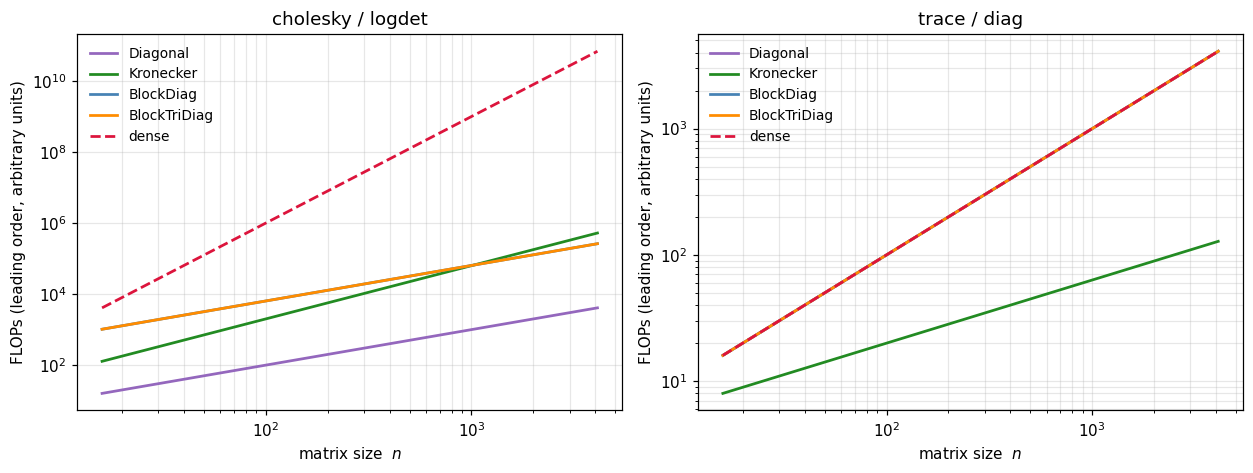

In [4]:
# Theoretical FLOP counts straight from the dispatch table.
# n is the total leading dimension; each operator has its parameters set so its size is n.
b = 8                                                # block size for BlockDiag / BlockTriDiag
ns = np.logspace(np.log10(16), np.log10(4096), 60)   # log-spaced sweep

# {primitive: {operator: flops(n)}}
flops = {
    "cholesky / logdet": {
        "Diagonal":     ns,                          # O(n)
        "Kronecker":    2 * ns**1.5,                 # O(n_A^3 + n_B^3) with n_A=n_B=sqrt(n)
        "BlockDiag":    (ns / b) * b**3,             # K=n/b blocks, b^3 each
        "BlockTriDiag": (ns / b) * b**3,             # same leading order
        "dense":        ns**3,                       # O(n^3)
    },
    "trace / diag": {
        "Diagonal":     ns,                          # O(n)
        "Kronecker":    2 * np.sqrt(ns),             # O(n_A + n_B)
        "BlockDiag":    ns,                          # K * b = n
        "BlockTriDiag": ns,                          # N * b = n
        "dense":        ns,                          # O(n)
    },
}

colors = {"Diagonal": "tab:purple", "Kronecker": "forestgreen",
          "BlockDiag": "steelblue", "BlockTriDiag": "darkorange",
          "dense": "crimson"}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=True)
for ax, (title, curves) in zip(axes, flops.items()):
    for op, y in curves.items():
        ls = "--" if op == "dense" else "-"
        ax.plot(ns, y, ls, lw=1.8, color=colors[op], label=op)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"matrix size  $n$")
    ax.set_ylabel("FLOPs (leading order, arbitrary units)")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout(); plt.show()

**Left panel** — `cholesky` / `logdet`. The dense curve climbs at $\mathcal{O}(n^3)$; the structured curves bend down sharply: `Kronecker` at $\mathcal{O}(n^{3/2})$, `BlockDiag` and `BlockTriDiag` at $\mathcal{O}(n)$ (for fixed block size), `Diagonal` also $\mathcal{O}(n)$. By $n = 4096$ the gap between dense and `Kronecker` is over four orders of magnitude.

**Right panel** — `trace` / `diag`. All operators land at $\mathcal{O}(n)$ or below; `Kronecker` even drops to $\mathcal{O}(\sqrt{n})$ because $\mathrm{tr}(A\otimes B) = \mathrm{tr}(A)\,\mathrm{tr}(B)$ only touches each factor's diagonal. These operations are cheap regardless — the win there is **storage** (you never materialise $A$), not flops.

This is the same conclusion we reached in [0.8 — structured sampling](structured_sampling.ipynb) for `cholesky`-via-`mv`: the structure-preserving primitive gives you sub-cubic scaling **without writing any custom code**. You just instantiate the right operator type, and gaussx routes through the closed-form path automatically.

## BlockDiag — independent components

Block-diagonal covariances arise whenever you have **independent** Gaussian sub-models — independent outputs in a multi-task GP, independent particles in an ensemble, independent agents in a multi-agent state-space. The dispatch acts on each block in parallel.

```{math}
:label: eq:logdet-blockdiag
\log\bigl\lvert\,\mathrm{diag}(A_1,\dots,A_K)\,\bigr\rvert \;=\; \sum_{k=1}^{K} \log\lvert A_k\rvert.
```

In [5]:
# BlockDiag of three SPD blocks of differing sizes.
keys = jax.random.split(jax.random.PRNGKey(11), 3)
blocks = [psd_op(random_psd(k, n, jitter=0.5)) for k, n in zip(keys, [4, 6, 5])]
A_bd = BlockDiag(*blocks)
A_de = psd_op(A_bd.as_matrix())

print(f"shape:                {A_bd.in_size()} x {A_bd.in_size()}")
print(f"cholesky type:        {type(cholesky(A_bd)).__name__}    (preserves block structure)")
print(f"logdet  struct/dense:  {float(logdet(A_bd)):>+.6f}  /  {float(logdet(A_de)):>+.6f}")
print(f"trace   struct/dense:  {float(gx_trace(A_bd)):>+.6f}  /  {float(gx_trace(A_de)):>+.6f}")
print(f"diag    ||struct - dense||: {float(jnp.linalg.norm(gx_diag(A_bd) - gx_diag(A_de))):.3e}")

shape:                15 x 15
cholesky type:        BlockDiag    (preserves block structure)


logdet  struct/dense:  +18.042260  /  +18.042260
trace   struct/dense:  +92.189598  /  +92.189598


diag    ||struct - dense||: 0.000e+00


**The Cholesky of a BlockDiag is a BlockDiag** — same structure-preserving idea as Kronecker. The $K$ blocks are factored independently (and in parallel under JIT), so the cost scales linearly in the number of blocks rather than cubically in their total size.

## Diagonal — the trivial case

The cheapest covariance is a diagonal one. All four primitives reduce to elementwise ops on the diagonal vector $d$:

```{math}
:label: eq:diag-primitives
\mathrm{cholesky}(\mathrm{diag}(d)) = \mathrm{diag}(\sqrt{d}), \quad \log\lvert \mathrm{diag}(d)\rvert = \sum_i \log d_i, \quad \mathrm{tr}(\mathrm{diag}(d)) = \sum_i d_i, \quad \mathrm{diag}(\mathrm{diag}(d)) = d.
```

This isn't just a curiosity — diagonal noise covariances $R = \sigma^2 I$ are **the** Gaussian assumption in observation models, and the per-output noise diagonals show up in heteroscedastic GPs (part 3.C).

In [6]:
# Diagonal operator — closed-form everything.
d = jnp.array([2.0, 0.5, 1.5, 0.1])
D = lx.DiagonalLinearOperator(d)

print(f"cholesky:  {jnp.asarray(cholesky(D).as_matrix()).diagonal()}        (= sqrt(d))")
print(f"logdet:    {float(logdet(D)):+.6f}             (= sum(log d))")
print(f"trace:     {float(gx_trace(D)):+.6f}             (= sum d)")
print(f"diag:      {jnp.asarray(gx_diag(D))}        (= d)")

cholesky:  [1.41421356 0.70710678 1.22474487 0.31622777]        (= sqrt(d))


logdet:    -1.897120             (= sum(log d))
trace:     +4.100000             (= sum d)
diag:      [2.  0.5 1.5 0.1]        (= d)


## Stochastic estimation — when even diag/trace are too expensive

For very large $A$ (e.g. an implicit kernel operator at scale, or the Hessian of a deep network), even the $\mathcal{O}(n)$ diagonal extraction is too costly when $A$ itself isn't materialised. gaussx supports **Hutchinson-style stochastic estimators** for `trace` and `diag`:

```{math}
:label: eq:hutchinson
\mathrm{tr}(A) \;=\; \mathbb{E}_{\varepsilon}\bigl[\,\varepsilon^\top A\,\varepsilon\,\bigr], \qquad \varepsilon_i \in \{\pm 1\} \text{ Rademacher}.
```

```{math}
:label: eq:bekas
\mathrm{diag}(A)_i \;\approx\; \frac{1}{N}\sum_{k=1}^{N} \varepsilon_i^{(k)} \,(A\varepsilon^{(k)})_i, \qquad \varepsilon^{(k)} \sim \{\pm 1\}^n.
```

[](#eq:hutchinson) is exact in expectation and uses only **matvecs** with $A$ — no factorisation. [](#eq:bekas) is the [Bekas–Kokiopoulou–Saad](https://www.sciencedirect.com/science/article/pii/S0168927407000244) probing estimator for the diagonal. Both are critical for the BBMM / Lanczos / SLQ stack in [part 1.E](#).

In [7]:
# Hutchinson stochastic trace via gaussx.trace's `n_samples=` argument.
key_st = jax.random.PRNGKey(123)
n_big = 64
A_big = psd_op(random_psd(jax.random.PRNGKey(99), n_big, jitter=1.0))

tr_exact = float(gx_trace(A_big))
tr_stoch_64  = float(gx_trace(A_big, stochastic=True, key=key_st, num_probes=64))
tr_stoch_256 = float(gx_trace(A_big, stochastic=True, key=key_st, num_probes=256))
tr_stoch_2k  = float(gx_trace(A_big, stochastic=True, key=key_st, num_probes=2048))

print(f"exact trace               : {tr_exact:>10.4f}")
print(f"stochastic trace (N=64)   : {tr_stoch_64:>10.4f}    rel. err {abs(tr_stoch_64-tr_exact)/abs(tr_exact):.3%}")
print(f"stochastic trace (N=256)  : {tr_stoch_256:>10.4f}    rel. err {abs(tr_stoch_256-tr_exact)/abs(tr_exact):.3%}")
print(f"stochastic trace (N=2048) : {tr_stoch_2k:>10.4f}    rel. err {abs(tr_stoch_2k-tr_exact)/abs(tr_exact):.3%}")

exact trace               :  4232.2136
stochastic trace (N=64)   :  4245.3880    rel. err 0.311%
stochastic trace (N=256)  :  4201.2455    rel. err 0.732%
stochastic trace (N=2048) :  4229.7748    rel. err 0.058%


The estimator's variance scales as $\mathcal{O}(1/N)$, so the relative error halves when you 4× the sample budget. For applications that only need an unbiased gradient estimate (e.g. log-determinant gradients via stochastic Lanczos quadrature, or score-function estimators of marginal likelihood), this is more than enough — you take a noisy estimate and let SGD average it out.

## Recap

- Four primitives — `cholesky`, `logdet`, `trace`, `diag` — power every Gaussian quantity in the curriculum: log-density [](#eq:logpdf-recipe), KL [](#eq:kl-recipe), entropy [](#eq:entropy-recipe), predictive marginals [](#eq:predmarg-recipe).
- All four dispatch structurally in gaussx: `Diagonal` / `BlockDiag` / `Kronecker` / `BlockTriDiag` / `LowRankUpdate` get closed-form $\mathcal{O}(n)$–$\mathcal{O}(n^{3/2})$ paths; everything else falls back to dense LAPACK.
- The Cholesky of a structured operator is itself a structured operator — `cholesky(Kronecker(A,B)) = Kronecker(L_A, L_B)` — so downstream `solve` / `mv` calls stay sub-cubic.
- Hutchinson / Bekas–Kokiopoulou stochastic estimators provide $\mathcal{O}(1/N)$ unbiased estimates of `trace` and `diag` for matrix-free operators where even $\mathcal{O}(n)$ extraction is too expensive — the entry point to BBMM-style scaling.

:::{seealso} Where this goes
- **0.10 — differentiating through `solve`** — the fifth primitive, with implicit-function-theorem gradients that reuse the same factorisation.
- **0.11 — numerical stability** — what to do when `cholesky` returns NaNs (jitter, safe Cholesky, condition number).
- **0.12 — stable RBF & squared distances** — kernel construction that keeps the matrix SPD before it ever reaches `cholesky`.
- **Part 1.E — log-det / trace at scale** — Stochastic Lanczos Quadrature for log-det, Bekas-Kokiopoulou for diag, BBMM for joint trace+logdet.
:::